# N3: normalization with uMAIA, making two sections comparable

### CAJAL NEUROMICS summer school, Bordeaux 2026 · a spatial metabolomics primer

*Luca Fusar Bassini · hands-on notebook · ~70 minutes*

---

In notebook N1 you pulled raw MALDI images from METASPACE and in N2 you annotated peaks into named
lipids. You now hold, for each of our two coronal sections, a table of pixels by lipids. One section
is a control female brain, the other is a pregnant female brain, cut at the *same* coronal plane
(roughly 6.5 mm behind bregma). The whole course builds toward one question: which lipids change in
pregnancy, and where in the brain.

Before we can ask that question we have to clear one trap. The two sections were not acquired at the
same moment. They sat on different slides, got coated with matrix at slightly different thicknesses,
and were hit by a laser whose energy drifts run to run, read out by a detector whose gain is not
fixed. So the *absolute intensity scale* is not the same in the two sections, for reasons that have
nothing to do with biology. If we compared raw intensities we would be measuring, in part, "which
slide was run on which day". That technical offset is a **batch effect**, and removing it is exactly
what this notebook is about.

The tool is **uMAIA** (github.com/lamanno-epfl/uMAIA), the normalization step at the front of the
EUCLID pipeline. We will do three things. First, see the batch effect with our own eyes on the real
data. Second, understand the probabilistic model uMAIA fits, and the elegant histogram-matching
correction it applies, by unrolling that correction in plain NumPy so nothing is a black box. Third,
be honest about a corner case: uMAIA was designed for stacks of many sections, and we are feeding it
exactly two, so we will see where that strains it and how we guard against it.

## the callouts

The same four markers run through every notebook in this course:

- 🔬 **TASK**: something you do (write or run code).
- 💡 **HINT**: a nudge when you are stuck.
- ❓ **QUESTION**: pause and think; no code required.
- ⚠️ **CHECKPOINT**: what you should see if it worked. If your screen disagrees, stop and fix it before moving on.

🔬 **TASK.** Run the next cell to load the libraries and set the course plotting style.

In [1]:
# the scientific-Python stack, plus the course helper package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

from scipy import stats               # gives us the normal CDF for the transform
from scipy.interpolate import interp1d  # inverts a CDF by interpolation

# the course helper package (installed editable as cajal_lipidomics)
import cajal_lipidomics as cl
from cajal_lipidomics import analysis   # the unrolled statistics, incl. min01_per_lipid
from cajal_lipidomics.style import set_style, FS
set_style()                            # clean, dense, Illustrator-editable panels

# one global seed so every number and figure below is reproducible
RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

plt.rcParams["figure.dpi"] = 110

# resolve the project root so the data paths below work from any working directory
import os
DATA = "data"
if not os.path.isdir(DATA):
    here = os.getcwd()
    for _ in range(5):                       # walk up until we find the data folder
        if os.path.isdir(os.path.join(here, "data")):
            DATA = os.path.join(here, "data")
            break
        here = os.path.dirname(here)

print("ready. numpy", np.__version__, "| anndata", ad.__version__)

ready. numpy 2.2.6 | anndata 0.12.10


/tmp/ipykernel_1026175/549122178.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("ready. numpy", np.__version__, "| anndata", ad.__version__)


⚠️ **CHECKPOINT.** You should see `ready. numpy ... | anndata ...` and no red error. If you
get a `ModuleNotFoundError`, your notebook is on the wrong kernel: pick the `cajal-lipidomics` kernel
in the top-right kernel picker.

## the two sections we will work on

We load the prepared substrate for the whole course: one AnnData object holding both sections
stacked together. `adata.X` is a matrix of pixels by lipids, `adata.var_names` are the lipid names,
and `adata.obs` carries the per-pixel metadata (which condition, which section, where in the brain).

🔬 **TASK.** Load it and read off the shape.

In [2]:
# the prepared two-section substrate (pixels x lipids), with all per-pixel metadata
adata = ad.read_h5ad(os.path.join(DATA, "sections_pair.h5ad"))

n_pixels, n_lipids = adata.shape
print(f"{n_pixels:,} pixels  x  {n_lipids} lipids")
print()
print("pixels per condition:")
print(adata.obs["Condition"].value_counts())
print()
print("first lipids:", list(adata.var_names[:6]))

174,768 pixels  x  173 lipids

pixels per condition:
Condition
pregnant    90447
naive       84321
Name: count, dtype: int64

first lipids: ['HexCer 42:2;O2', 'HexCer 42:1;O2', 'HexCer 40:1;O2', 'PC 38:6', 'PA 34:1', 'SM 36:1;O2']


⚠️ **CHECKPOINT.** 174,768 pixels and 173 lipids, split into `naive` (the control female, about
84k pixels) and `pregnant` (about 90k pixels). The lipid names read as a class plus a chain summary:
`HexCer 42:2;O2` is a hexosylceramide with 42 acyl carbons and 2 double bonds, a sphingolipid that
marks myelin. We met that naming in N2.

One honest note up front. This substrate has *already* been through uMAIA, because every downstream
notebook needs comparable values. So we are in a slightly unusual teaching position: we will use this
clean data to *understand* what normalization does and to demonstrate the correction mechanism, rather
than running the heavy fit live. That is on purpose. The fit needs a separate JAX/NumPyro environment
(more on that below), and the value for you is in seeing the mechanics, not in waiting for an
optimizer.

## what a batch effect is, in one picture

MALDI-MSI acquires one mass spectrum per pixel. A whole tissue section is one **acquisition**: one
laser run, one matrix coating, one instrument session. Between acquisitions several non-biological
things drift:

- **matrix crystallization**: the light-absorbing matrix is sprayed onto the slide and crystallizes;
  thicker or finer crystals desorb more or less material.
- **laser energy**: the pulse energy is not identical shot to shot or day to day.
- **detector gain and ionization efficiency**: the electronics and the ionization yield wander.
- **sample height**: a section sitting microns higher or lower changes the focus.

The net effect is simple to state and dangerous to ignore: **the same lipid at the same true
abundance reads a different raw intensity in section A than in section B.** That difference is the
batch effect. It is not random noise scattered pixel by pixel; it is a coherent shift of the whole
section's intensity scale.

Here is why it matters for us. If pregnant pixels read systematically brighter than control pixels
for purely technical reasons, a naive comparison would call every lipid "up in pregnancy". We would
be reporting the slide, not the biology. Normalization is the step that strips the slide back out.

🔬 **TASK.** First, look at the two sections side by side so the geometry is concrete. We color each
pixel by its Allen brain region using the stored anatomy colors. They are the same coronal plane, so
the shapes should match.

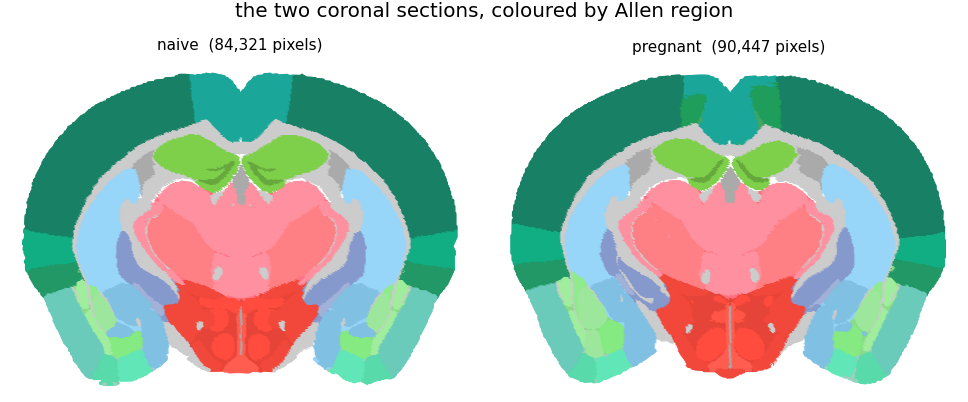

In [3]:
# plot both sections coloured by Allen anatomical region (stored hex colours)
secs = ["naive", "pregnant"]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, cond in zip(axes, secs):
    m = (adata.obs["Condition"] == cond).to_numpy()
    ax.scatter(adata.obs.loc[m, "zccf"], -adata.obs.loc[m, "yccf"],
               c=adata.obs.loc[m, "allencolor"], s=2, rasterized=True)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(f"{cond}  ({m.sum():,} pixels)", fontsize=FS["m"])
fig.suptitle("the two coronal sections, coloured by Allen region", fontsize=FS["l"])
plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** Two coronal brain slices of nearly identical shape, painted in the Allen
color scheme. Same plane, same anatomy, different mouse and different acquisition. That is the ideal
setup for spotting a batch effect: when the *anatomy* is matched, any blanket intensity difference
between the slides is suspicious.

❓ **QUESTION.** A batch effect shifts a whole section's intensity scale at once. A real biological
difference changes specific lipids in specific places. Keep that contrast in mind: normalization tries
to remove the first without touching the second. How could a method possibly tell them apart from the
numbers alone? Hold the question; the model below is one answer.

## the key empirical fact: per-molecule histograms are bimodal in log space

uMAIA does not just rescale each image by a constant. It leans on a specific structure that real
MALDI data has. Take one lipid, collect its intensity across all the pixels of one section, and plot
the histogram **in log space**. You typically see *two humps*, not one:

- a low **background mode**: pixels where this lipid is essentially absent, so you are measuring
  matrix noise and baseline. These pixels pile up at a low, roughly fixed value.
- a higher **foreground mode**: pixels where the lipid is genuinely present at biological levels.

Why log space? Intensities span orders of magnitude and pile up near zero on a linear axis, where the
two modes smear into one blurry blob. Taking the logarithm stretches the small values apart and the
two humps separate cleanly. We add a tiny offset `epsilon` before the log so that pixels reading
exactly zero do not blow up to minus infinity; uMAIA uses `epsilon = 2e-4`.

🔬 **TASK.** Build the per-molecule log histogram for a myelin lipid, `HexCer 42:2;O2`, in the control
section. Watch for two humps.

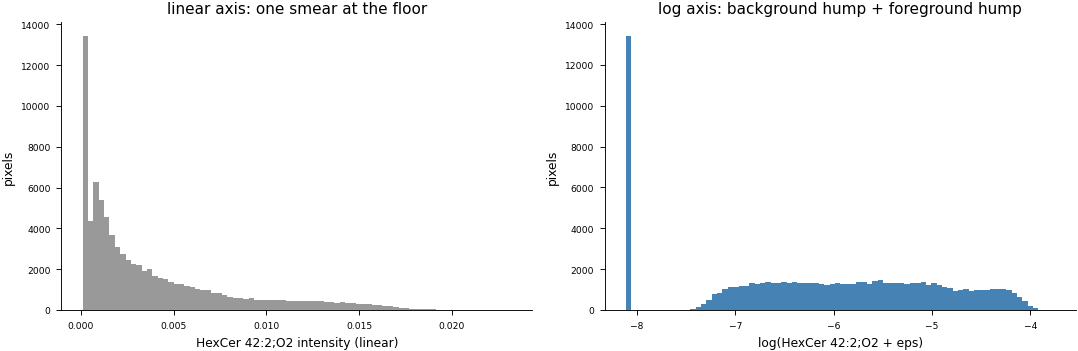

16% of control pixels sit at the background floor for HexCer 42:2;O2


In [4]:
# pick one lipid and one section; collect its intensities across all pixels
lipid = "HexCer 42:2;O2"
j = list(adata.var_names).index(lipid)
X = np.asarray(adata.X)                       # pixels x lipids
eps = 2e-4                                     # uMAIA's log offset

m_ctrl = (adata.obs["Condition"] == "naive").to_numpy()
vals = X[m_ctrl, j]                            # this lipid's intensity in every control pixel

# the foreground/background split is invisible on a linear axis, obvious in log space
log_vals = np.log(np.clip(vals, 0, None) + eps)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(vals, bins=80, color="0.6")
axes[0].set_xlabel(f"{lipid} intensity (linear)"); axes[0].set_ylabel("pixels")
axes[0].set_title("linear axis: one smear at the floor")

axes[1].hist(log_vals, bins=80, color="steelblue")
axes[1].set_xlabel(f"log({lipid} + eps)"); axes[1].set_ylabel("pixels")
axes[1].set_title("log axis: background hump + foreground hump")
plt.tight_layout(); plt.show()

frac_floor = float((log_vals < np.log(eps) + 0.5).mean())
print(f"{frac_floor*100:.0f}% of control pixels sit at the background floor for {lipid}")

⚠️ **CHECKPOINT.** On the linear axis everything crushes against zero. On the log axis you see
the structure: a sharp spike at the very bottom (the background floor, where the lipid is absent and
about 16% of pixels live) and a broad hump to the right (the foreground, the white-matter pixels where
this myelin lipid is genuinely abundant). Not every lipid is this clearly bimodal, but many are, and
that is the structure uMAIA exploits.

The crucial asymmetry, established in the uMAIA paper: **the batch effect acts mostly on the
foreground mode.** The background mode is matrix noise and stays roughly put across acquisitions, so
it works as an anchor. The foreground mode is where the real signal is, and that is the mode the slide
drifts. So the job is to figure out how the foreground mode got shifted on each slide and slide it
back onto a common reference, while leaving the background anchor and the within-section structure
alone.

🔬 **TASK.** Now overlay the *same lipid* from the two sections, in log space, to see whether
their foreground modes sit at the same place. This is the batch effect, if it is there.

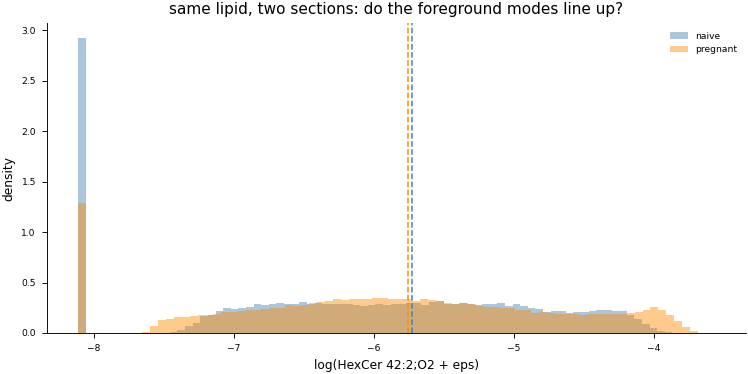

In [5]:
# overlay the log histogram of the SAME lipid in the two sections
fig, ax = plt.subplots(figsize=(7, 3.6))
for cond, colour in [("naive", "steelblue"), ("pregnant", "darkorange")]:
    m = (adata.obs["Condition"] == cond).to_numpy()
    lv = np.log(np.clip(X[m, j], 0, None) + eps)
    ax.hist(lv, bins=80, density=True, histtype="stepfilled", alpha=0.45,
            color=colour, label=cond)
    ax.axvline(np.median(lv[lv > np.log(eps) + 0.5]), color=colour, ls="--", lw=1)
ax.set_xlabel(f"log({lipid} + eps)"); ax.set_ylabel("density")
ax.set_title("same lipid, two sections: do the foreground modes line up?")
ax.legend(); plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** The two background floors sit on top of each other (the anchor), and the two
foreground humps are *close* but not perfectly aligned; the dashed lines mark each section's
foreground median. Because this substrate is already uMAIA-normalized, the residual offset here is
small, which is the whole point: normalization already pulled the foreground modes most of the way
into register. On raw, un-normalized data the gap between the two humps would be larger and obviously
technical. Below we will reproduce that raw situation in a controlled simulation and watch the
correction close the gap exactly.

## the uMAIA model: a mixture per (lipid, section), with a rank-1 batch term

Now the model. uMAIA fits, for every (lipid, section) pair, a **two-component Gaussian mixture in log
space**: one Gaussian for the background mode, one for the foreground mode. The clever part is how the
foreground mode's position is parameterized. Write `x` for a pixel's log-intensity of compound `c` in
acquisition (section) `a`. The generative model, read off uMAIA's `_model.py` on its default path
(`delta_v_dist='gaussian'`, the branch that `normalize()` actually passes), is:

```
# --- per-lipid parameters: one value per compound c, SHARED across sections ---
delta_v_c ~ Gamma(5.0, 2.0)      # prior mean 2.5: the typical fg-minus-bg gap on the log scale
delta_c   ~ Normal(delta_v_c, 0.25)   # this lipid's mode gap, tight around delta_v_c
locs_c    ~ Normal(m0, 1)        # background mean = the anchor, ONE per lipid (not per section)
lambda_c  ~ Uniform(-2, 2)       # how susceptible THIS lipid is to batch drift
sigma_v_c ~ Exponential(.)       # per-lipid piece of the foreground standard deviation

# --- per-section parameters: one value per acquisition a ---
gamma_a   ~ Uniform(-2, 2)       # how strong the drift is on THIS slide
sigma_s_a ~ Exponential(.)       # per-slide piece of the foreground standard deviation

# --- assembled per (lipid, section) ---
mu0_ac    = locs_c                                  # background mean (the anchor), per lipid
mu1_ac    = locs_c + gamma_a * lambda_c + delta_c   # foreground mean
scale1_ac = sigma_s_a + sigma_v_c                   # foreground sd, built ADDITIVELY
pi_ca     ~ Dirichlet(0.5, 0.5)  # mixture weights: how much background vs foreground
z_p       ~ Bernoulli(pi_ca)     # per-pixel latent label: is this pixel bg or fg?
x_p       ~ z * Normal(mu1, scale1) + (1 - z) * Normal(mu0, sigma0)
```

A note on what is per-lipid versus per-section, because it is easy to get wrong: in the code `locs`
(the background anchor) is sampled **per lipid only**, one vector over compounds, not one per (lipid,
section). The only things that carry a section index are `gamma_a` and `sigma_s_a`. So the background
mean of a given lipid is the same value the model tries to place under every section's background hump,
which is exactly what makes it an anchor.

Read the foreground-mean line slowly, because it is the heart of the method:

$$\mu^{1}_{ac} \;=\; \underbrace{\text{locs}_{c}}_{\text{background anchor (per lipid)}} \;+\; \underbrace{\gamma_a \cdot \lambda_c}_{\text{batch shift}} \;+\; \underbrace{\delta_c}_{\text{biological mode gap}}$$

The batch shift is **rank-1**: it is one scalar per slide, `gamma_a`, times one scalar per lipid,
`lambda_c`. That factorization is the modeling assumption that does all the work. It says: every
slide has a single "how bad is my drift" number, and every lipid has a single "how much do I respond
to drift" number, and the shift on a given (slide, lipid) is just their product. The paper justifies
this empirically: take the matrix of measured technical errors and do an SVD, and the first singular
value dominates, meaning one slide-factor times one lipid-factor explains most of the technical
variance.

`delta_c` is the systematic, biological distance between the background and foreground modes, the same
across slides for a given lipid. Its prior on the default path is **Gamma(5.0, 2.0), whose mean is
2.5** on the log scale, with `delta_c` itself drawn tightly (`Normal(delta_v_c, 0.25)`) around that
per-lipid mean. There is a second branch in the code, `delta_v_dist='gamma'`, where `delta` instead
gets a `Normal(3.0, 0.8)` prior, but that branch is not the one `normalize()` selects, so do not read
the gap prior as "centered at 3". On the path we actually run, the typical mode gap the model expects
is about 2.5 log units. So the foreground mean is the background anchor, plus a biological gap that
should not be touched, plus a technical shift that should be removed. Normalization removes
`gamma_a * lambda_c` and leaves `delta_c` and the anchor in place.

A subtlety worth flagging: the foreground standard deviation is built **additively**, `scale1 =
sigma_s_a + sigma_v_c`, a per-slide piece plus a per-lipid piece (each with an `Exponential` prior),
not the usual square-root-of-sum-of-squares. The code also carries a small extra slack term `error`
per (slide, lipid) that absorbs deviations from the strict rank-1 structure. These are implementation
details; the rank-1 batch shift is the idea to remember.

### how it is fit: MAP via SVI, not posterior sampling

uMAIA fits this model with **stochastic variational inference (SVI)** using an `AutoDelta` guide. That
phrase has a simple meaning. A delta-function guide collapses the "posterior" to a single point, so
SVI here is doing **maximum-a-posteriori (MAP)** estimation: it finds the single most probable set of
parameter values, with the priors acting as gentle regularizers, by gradient descent (Adam). There is
**no MCMC and there are no posterior samples.** Think "regularized best-fit point estimate", not
"Bayesian sampling". The discrete per-pixel labels `z` are marginalized analytically by enumeration,
so the optimizer only ever sees continuous parameters. With a fixed seed the result is deterministic.

Operationally, on the two course sections, the call looks like the illustrative cell below. We do
**not** run it here, for two reasons. First, the fit needs JAX and NumPyro pinned to specific versions
(`jax==0.4.14`, `numpyro==0.12.1`), a separate environment from this teaching kernel. Second, the value
for you is the *mechanism*, which we unroll in plain NumPy in the next section. Read this cell as
documentation of the real API; do not expect it to execute.

In [6]:
# ILLUSTRATIVE ONLY: needs a separate jax/numpyro environment; do NOT run here.
# This cell is tagged raises-exception, so `jupyter nbconvert --execute` runs it,
# sees the expected ModuleNotFoundError on `import uMAIA`, records it, and keeps going
# (the rest of the notebook still executes clean). It documents the real uMAIA API.
import uMAIA, numpy as np, os                                   # noqa

acquisitions = ["control_section", "pregnant_section"]          # our 2 sections
PATH_SAVE = "data/TestStack.zarr"                               # matched images (zarr)
small_num = 2e-4                                                # the log offset epsilon

# 1) load images + tissue masks into a dense (N pixels, S sections, V molecules) tensor,
#    log-transformed: read_images_masks zero-pads shorter sections and marks pads False.
mask_list = [np.load(f"data/{a}/mask.npy") for a in acquisitions]
x, masks, masks_list = uMAIA.ut.tools.read_images_masks(
    acquisitions, path_images=PATH_SAVE, mask_list=mask_list,
    gaussian_smoothing=True, gaussian_sigma=0.4,
    log_transform=True, epsilon=small_num)                      # x is LOG-intensity

# 2) GMM-based init: per molecule, fit a 1- and a 2-component Gaussian mixture and keep the
#    one with the lower BIC. This is where the background/foreground modes come from.
init_state = uMAIA.norm.initialize(x, masks, subsample=True)

# 3) the only heavy step: MAP fit via SVI (AutoDelta guide). covariate_vector
#    stays None. We deliberately do NOT tell the model which section is pregnant.
svi_result = uMAIA.norm.normalize(
    x, masks, init_state=init_state, subsample=True,
    num_steps=5000, seed=42)                                    # rank=1, deterministic

# 4) apply the histogram-matching correction (unrolled below) -> normalized LOG tensor
x_MAIA = uMAIA.norm.transform(x, masks, svi_result)

# 5) write the normalized images back out for the downstream EUCLID steps
uMAIA.ut.tools.to_zarr_normalised(PATH_SAVE, "data/TestStack_normalised.zarr",
                                  acquisitions, x_MAIA, mask_list, small_num)

ModuleNotFoundError: No module named 'uMAIA'

💡 **HINT.** Two things to notice in that cell. The fit subsamples to about 2,500 pixels per
section, which is why it runs in minutes on a CPU even for the whole atlas. And `covariate_vector`
is left at its default `None`: we are *not* handing the model the biological labels. The reason is in
the next-to-last section; for now, trust that telling the normalizer "this section is pregnant" would
let it absorb the very biology we want to test.

## unrolling the correction: histogram matching by CDF and inverse-CDF

This is the part worth doing by hand, because it is the whole answer to "what does normalization
actually *do* to a number". It is about twenty lines of NumPy and SciPy, and once you see it you will
never find quantile matching mysterious again.

The idea. Suppose the measured log-intensity distribution of a lipid in one section, call it
$g(x)$, is a distorted version of a shared reference distribution $f(y)$ that we want every section to
match. We relate the two through their **cumulative distribution functions (CDFs)**. A CDF $F(y)$
answers "what fraction of the data is below $y$"; it climbs from 0 to 1 and is a one-to-one map between
a value and its **quantile** (its rank, as a fraction). So the correction is:

$$y \;=\; F^{-1}\big(\,G(x)\,\big)$$

In words, three steps for each measured value $x$:

1. push $x$ through its **own** fitted mixture CDF $G$ to get its quantile $q = G(x)$, a number in
   $[0,1]$ that says "this value is at the $q$-th percentile of its section".
2. take that same quantile $q$.
3. pull it back through the **reference** inverse-CDF $F^{-1}$ to get the value that sits at the
   $q$-th percentile of the shared reference.

The value at the 90th percentile of section A becomes the value at the 90th percentile of the
reference. This is **quantile (histogram) matching**. Because the CDFs are the smooth fitted
two-Gaussian mixtures, not jagged empirical CDFs, the map is smooth, monotone (order-preserving, so it
never reshuffles pixels), and conservative. The background anchor and the within-section ranking
survive; only the technical stretch of the scale is removed.

🔬 **TASK.** Build the two helpers, copied faithfully from uMAIA's `_transform.py`: a mixture CDF, and
a routine that inverts a reference mixture CDF by interpolation. Read the comments.

In [7]:
# --- the two transparent pieces of uMAIA's histogram-matching correction ---
# (these mirror cdf_mixture / make_inv_cdf in uMAIA/normalization/_transform.py)

def cdf_mixture(x, mu1, mu2, sigma1, sigma2):
    # Equal-weight two-Gaussian mixture CDF: the average of two normal CDFs.
    # mu1/sigma1 describe the background mode, mu2/sigma2 the foreground mode.
    # G(x) returns the quantile of x under this fitted mixture.
    return (stats.norm.cdf(x, mu1, sigma1) + stats.norm.cdf(x, mu2, sigma2)) / 2.0

def make_inv_cdf(mu1, mu2, sigma1, sigma2, resolution=2000, rel_range=6):
    # Build F^{-1} for a reference mixture by tabulating its CDF and inverting it.
    # Lay a fine grid over the value axis (+/- 6 sigma around the two modes),
    # compute the mixture CDF on that grid, then interpolate the OTHER way:
    # from cdf value (a quantile) back to the value. interp1d gives us F^{-1}.
    mu_min, mu_max = min(mu1, mu2), max(mu1, mu2)
    sigma_max = max(sigma1, sigma2)
    domain = np.linspace(mu_min - rel_range * sigma_max,
                         mu_max + rel_range * sigma_max, resolution)
    cdf_vals = cdf_mixture(domain, mu1, mu2, sigma1, sigma2)
    # invert: map quantile -> value
    return interp1d(cdf_vals, domain, bounds_error=False,
                    fill_value="extrapolate", copy=True)

def transform_byicdf(x, mu1x, mu2x, sigma1x, sigma2x, icdf_ref):
    # The F^{-1}(G(x)) map: quantile under the source CDF, value under the reference.
    return icdf_ref(cdf_mixture(x, mu1x, mu2x, sigma1x, sigma2x))

print("built cdf_mixture, make_inv_cdf, transform_byicdf")

built cdf_mixture, make_inv_cdf, transform_byicdf


💡 **HINT.** `interp1d(cdf_vals, domain)` looks backwards at first glance, and that is exactly
the trick. A normal CDF maps value to quantile. By handing `interp1d` the quantiles as the x-argument
and the values as the y-argument, we get a function that maps quantile back to value, which is
$F^{-1}$. The `make_inv_cdf` in uMAIA does precisely this, on a 2000-point grid.

### a controlled demo: two mismatched histograms snapping into register

Real normalized data has only a small residual offset, so to *see* the mechanism clearly we first
build a controlled example: two simulated sections of the same lipid, each a background hump plus a
foreground hump, where section B's foreground has been shifted and stretched by a fake batch effect.
This is exactly the situation on raw data. Then we apply the CDF/inverse-CDF map to push both onto a
shared reference and watch the foreground modes line up.

🔬 **TASK.** Simulate the two mismatched histograms.

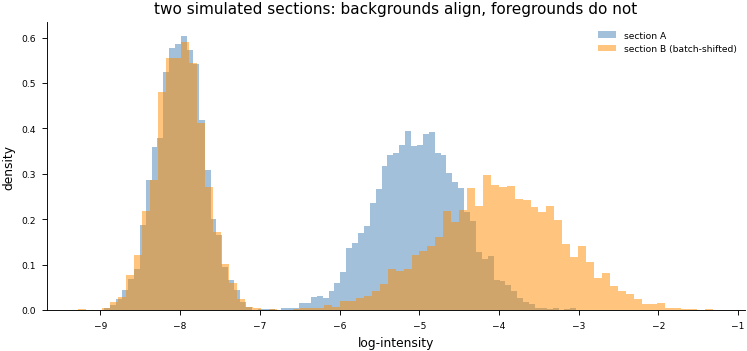

In [8]:
# --- simulate two sections of one lipid: a bg mode + a fg mode each, in LOG space ---
n = 8000
# section A: background at -8, foreground at -5 (this is "well-behaved")
muA_bg, muA_fg, sA_bg, sA_fg = -8.0, -5.0, 0.30, 0.55
# section B: SAME biology, but a batch effect shifted+stretched its FOREGROUND mode
muB_bg, muB_fg, sB_bg, sB_fg = -8.0, -4.0, 0.30, 0.80   # fg pushed right and widened

def sample_mixture(mu_bg, mu_fg, s_bg, s_fg, w_fg=0.55, n=n, seed=0):
    r = np.random.default_rng(seed)
    is_fg = r.random(n) < w_fg                          # per-pixel bg/fg label
    out = np.where(is_fg, r.normal(mu_fg, s_fg, n), r.normal(mu_bg, s_bg, n))
    return out

A = sample_mixture(muA_bg, muA_fg, sA_bg, sA_fg, seed=1)
B = sample_mixture(muB_bg, muB_fg, sB_bg, sB_fg, seed=2)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(A, bins=80, density=True, alpha=0.5, color="steelblue", label="section A")
ax.hist(B, bins=80, density=True, alpha=0.5, color="darkorange", label="section B (batch-shifted)")
ax.set_xlabel("log-intensity"); ax.set_ylabel("density")
ax.set_title("two simulated sections: backgrounds align, foregrounds do not")
ax.legend(); plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** The two background humps sit on top of each other near -8 (the stable
anchor), but section B's foreground hump is shoved right to -4 and is wider, while section A's sits at
-5. That gap is the batch effect we want gone.

🔬 **TASK.** Now build the **shared reference** the way uMAIA does (paper Eq 7): the reference mixture
parameters are the **mean over sections** of the fitted per-section parameters. With two sections that
is just the midpoint. Then map each section through `F_ref^{-1}(G_section(x))`.

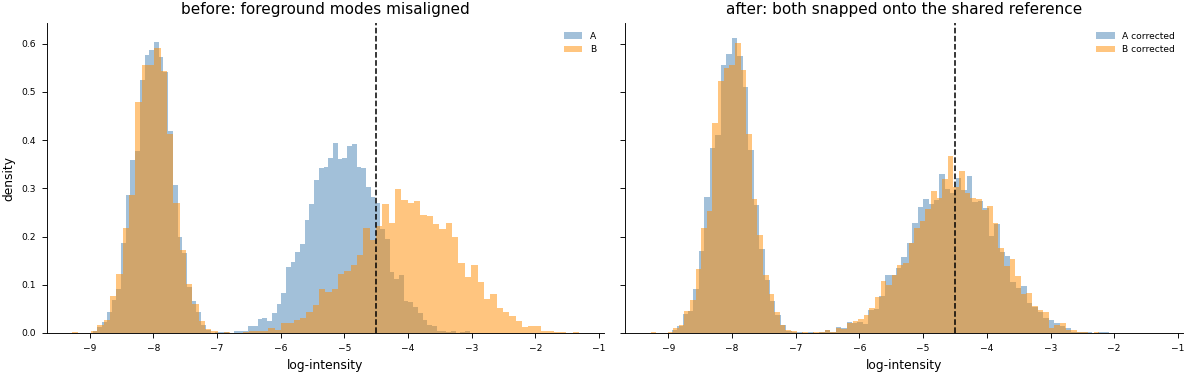

before: A fg median -5.01, B fg median -4.00
after:  A fg median -4.51, B fg median -4.50  (reference fg = -4.50)


In [9]:
# --- shared reference = mean of the two sections' fitted mixture parameters (Eq 7) ---
ref_bg = (muA_bg + muB_bg) / 2          # -8.0
ref_fg = (muA_fg + muB_fg) / 2          # -4.5, the midpoint of the two foreground modes
ref_s_bg = (sA_bg + sB_bg) / 2
ref_s_fg = (sA_fg + sB_fg) / 2

# one reference inverse-CDF, shared by both sections
icdf_ref = make_inv_cdf(ref_bg, ref_fg, ref_s_bg, ref_s_fg)

# push each section through its OWN CDF, then back through the reference inverse-CDF
A_corr = transform_byicdf(A, muA_bg, muA_fg, sA_bg, sA_fg, icdf_ref)
B_corr = transform_byicdf(B, muB_bg, muB_fg, sB_bg, sB_fg, icdf_ref)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True, sharey=True)
axes[0].hist(A, bins=80, density=True, alpha=0.5, color="steelblue", label="A")
axes[0].hist(B, bins=80, density=True, alpha=0.5, color="darkorange", label="B")
axes[0].axvline(ref_fg, color="k", ls="--", lw=1)
axes[0].set_title("before: foreground modes misaligned"); axes[0].legend()
axes[0].set_xlabel("log-intensity"); axes[0].set_ylabel("density")

axes[1].hist(A_corr, bins=80, density=True, alpha=0.5, color="steelblue", label="A corrected")
axes[1].hist(B_corr, bins=80, density=True, alpha=0.5, color="darkorange", label="B corrected")
axes[1].axvline(ref_fg, color="k", ls="--", lw=1)
axes[1].set_title("after: both snapped onto the shared reference"); axes[1].legend()
axes[1].set_xlabel("log-intensity")
plt.tight_layout(); plt.show()

print(f"before: A fg median {np.median(A[A>-6.5]):.2f}, B fg median {np.median(B[B>-6.5]):.2f}")
print(f"after:  A fg median {np.median(A_corr[A_corr>-6.5]):.2f}, "
      f"B fg median {np.median(B_corr[B_corr>-6.5]):.2f}  (reference fg = {ref_fg:.2f})")

⚠️ **CHECKPOINT.** After the transform, both foreground modes land on the dashed reference line
at -4.5, the midpoint, and the printed medians confirm it. The two distributions now overlap. We did
not subtract a constant or divide by a scalar; we matched quantiles through fitted CDFs, which lets
the correction be different in the foreground than in the background. The background anchor barely
moved, the foreground modes converged, and within each section every pixel kept its rank. That is
exactly the conservative, non-linear rescaling we wanted.

❓ **QUESTION.** Notice the reference is the *average* of the two sections. With two sections, that
midpoint is pulled equally by both. What would happen to the stability of this reference if one of the
two sections were an outlier slide? Hold that thought for the corner-case section.

### the same idea on the real substrate

Now the real data. The substrate is already uMAIA-normalized, so the residual cross-section offset is
small, and that creates a teaching problem: on a lipid whose two sections happen to differ at the
*background* as well, an independent per-section GMM finds two slightly different background means, and
the midpoint reference then nudges the background floors apart instead of holding them as an anchor.
That is a real artifact of fitting each section on its own, and it would muddy the lesson.

So we choose the demo lipid deliberately. We want one where the two sections' **backgrounds already sit
on top of each other** (a genuine shared anchor) and the **foregrounds differ enough to see**, so the
mechanism shows cleanly: the anchor should stay put while the foregrounds converge. `HexCer 42:1;O2`,
the next hexosylceramide along, fits: its background floors coincide at the same value in both sections
while its foreground modes sit about 0.16 log units apart. We will quantify both the background and the
foreground before and after, and check that only the foreground moves.

🔬 **TASK.** Pick `HexCer 42:1;O2`, fit a quick two-component mixture per section with scikit-learn,
then run the same transform. The Gaussian-mixture fit here stands in for uMAIA's GMM initialization
step: per molecule, find the background and foreground modes.

In [10]:
import warnings
from sklearn.mixture import GaussianMixture
from sklearn.exceptions import ConvergenceWarning

# deliberately chosen demo lipid: its backgrounds coincide (true anchor), foregrounds differ.
demo_lipid = "HexCer 42:1;O2"
jd = list(adata.var_names).index(demo_lipid)

# fit a two-component Gaussian mixture per section on the LOG values (all pixels).
# this stands in for uMAIA's GMM init: per molecule, find the bg and fg modes.
# (the background floor is a near-degenerate spike, so sklearn warns it did not fully
#  converge that thin component; the two mode MEANS are stable, so we quiet the warning.)
def fit_two_modes(log_x):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        g = GaussianMixture(n_components=2, random_state=RNG_SEED).fit(log_x.reshape(-1, 1))
    order = np.argsort(g.means_.ravel())        # lower mean = background, higher = foreground
    mu = g.means_.ravel()[order]
    sd = np.sqrt(g.covariances_.ravel())[order]
    return mu[0], mu[1], sd[0], sd[1]           # mu_bg, mu_fg, sigma_bg, sigma_fg

logs = {}
params = {}
for cond in ["naive", "pregnant"]:
    m = (adata.obs["Condition"] == cond).to_numpy()
    lv = np.log(np.clip(X[m, jd], 0, None) + eps)
    logs[cond] = lv
    params[cond] = fit_two_modes(lv)
    print(f"{cond:9s}: bg mu={params[cond][0]:.2f}  fg mu={params[cond][1]:.2f}")

# the two backgrounds nearly coincide (the shared anchor); the foregrounds differ
print(f"\nbackground gap between sections: {abs(params['naive'][0]-params['pregnant'][0]):.3f}  "
      f"(tiny: a real anchor)")
print(f"foreground gap between sections: {abs(params['naive'][1]-params['pregnant'][1]):.3f}  "
      f"(visible: what we want to close)")

# shared reference = mean of the two sections' fitted params (Eq 7, midpoint for S=2)
ref = np.mean([params["naive"], params["pregnant"]], axis=0)
icdf_real = make_inv_cdf(ref[0], ref[1], ref[2], ref[3])

corr = {c: transform_byicdf(logs[c], *params[c], icdf_real) for c in ["naive", "pregnant"]}

naive    : bg mu=-8.11  fg mu=-6.18


pregnant : bg mu=-8.11  fg mu=-6.32

background gap between sections: 0.001  (tiny: a real anchor)
foreground gap between sections: 0.145  (visible: what we want to close)


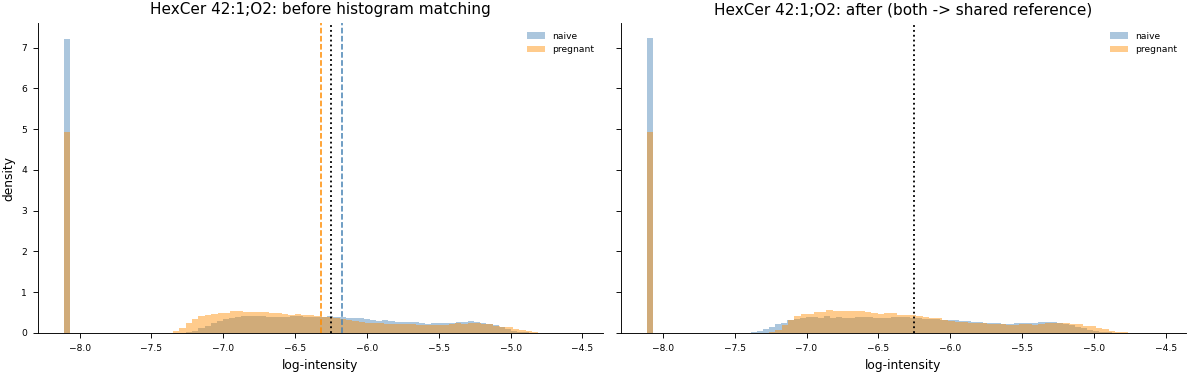

background-mode gap  before: 0.000   after: 0.000   (anchor: stays put)
foreground-mode gap  before: 0.178   after: 0.082   (drift: closes)


In [11]:
# before/after overlay on the REAL lipid
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True, sharey=True)
for cond, colour in [("naive", "steelblue"), ("pregnant", "darkorange")]:
    axes[0].hist(logs[cond], bins=80, density=True, alpha=0.45, color=colour, label=cond)
    axes[1].hist(corr[cond], bins=80, density=True, alpha=0.45, color=colour, label=cond)
    axes[0].axvline(params[cond][1], color=colour, ls="--", lw=1)   # each section's fg mode
axes[0].axvline(ref[1], color="k", ls=":", lw=1.2)                  # shared reference fg
axes[1].axvline(ref[1], color="k", ls=":", lw=1.2)
axes[0].set_title(f"{demo_lipid}: before histogram matching")
axes[1].set_title(f"{demo_lipid}: after (both -> shared reference)")
for a in axes:
    a.set_xlabel("log-intensity"); a.legend()
axes[0].set_ylabel("density")
plt.tight_layout(); plt.show()

# quantify BOTH modes before vs after: the foreground should converge, the background hold
cut = (ref[0] + ref[1]) / 2                       # split point between the two modes
def bg_median(v):  return float(np.median(v[v < cut]))
def fg_median(v):  return float(np.median(v[v > cut]))

bg_before = abs(bg_median(logs["naive"]) - bg_median(logs["pregnant"]))
bg_after  = abs(bg_median(corr["naive"]) - bg_median(corr["pregnant"]))
fg_before = abs(fg_median(logs["naive"]) - fg_median(logs["pregnant"]))
fg_after  = abs(fg_median(corr["naive"]) - fg_median(corr["pregnant"]))
print(f"background-mode gap  before: {bg_before:.3f}   after: {bg_after:.3f}   (anchor: stays put)")
print(f"foreground-mode gap  before: {fg_before:.3f}   after: {fg_after:.3f}   (drift: closes)")

⚠️ **CHECKPOINT.** This is the mechanism on real measurements, and now it reads cleanly. The two
**background** floors were already on top of each other (gap about 0.00) and they stay there after the
transform: the anchor does not move, which is exactly the claim from the simulation. The two
**foreground** modes started about 0.18 log units apart and the printed "after" gap is roughly half
that, with both section medians pulled in toward the black reference line. So only the drifting mode
moved, the anchor held, and within each section every pixel kept its rank. That is the conservative,
non-linear rescaling we wanted, confirmed on genuine data and not just a toy.

One honest caveat about the size of the effect. This substrate is **already** uMAIA-normalized, so the
residual offset we are closing here is small by construction: a fraction of a log unit, not the large
technical gap you would see on raw images. The point of this real-data panel is to show that the
*direction* and *selectivity* of the correction are right (foreground in, background fixed), not to
rescue a badly misaligned lipid. And the result does depend on choosing a lipid whose backgrounds
genuinely coincide: had we kept a lipid whose independent per-section GMM placed the two backgrounds at
different means, the midpoint reference would have nudged those floors apart and the "anchor" story
would have been muddied. uMAIA sidesteps that on the full atlas by sharing one background anchor
(`locs`, per lipid) across all sections from its joint MAP fit, rather than fitting each section's
background on its own as our quick per-section GMM does.

A few honest implementation notes, so the helper does not feel like magic when you call it later. The
reference mixture in uMAIA's `_transform.py` uses **equal 0.5/0.5 weights**, ignoring the fitted
mixture weights, and widens the reference foreground standard deviation by a factor of three
(`sigma_v * 3`), an empirical choice. The correction removes the batch term `gamma_a * lambda_c +
error` from the foreground mean and keeps the background anchor `locs` and the biological gap `delta`
intact. This is exactly what uMAIA does for all 173 lipids at once, using the modes it learned from the
joint MAP fit rather than a quick per-section GMM. These are the kinds of small, pragmatic decisions
you only learn by reading the code, which is why we read it.

## the honest corner case: uMAIA with only two sections

uMAIA was built for **stacks of many consecutive sections** of the same structure, dozens of slices
through a brain or a zebrafish, where biology varies smoothly from one section to the next and any
sharp section-to-section jump is almost certainly a batch effect. With that ensemble it can triangulate
the technical drift against the smooth biological trend. We are handing it **exactly two sections**,
one control and one pregnant. Several assumptions strain. Be honest about all of them.

1. **The reference is the mean of just two acquisitions.** Eq 7 averages the fitted foreground modes
   over sections; with two sections that is the midpoint of control and pregnant, with no larger
   ensemble to stabilize it. You saw this above: the reference sits exactly between the two and is
   pulled equally by both. If either slide were an outlier, the reference would follow it.

2. **No smoothness prior to lean on.** With many consecutive sections, uMAIA assumes biology changes
   slowly and high-frequency jumps are batch. With two sections there is no third slice to define
   "smooth", so the model cannot cleanly tell "section 2 is a different batch" from "section 2 is
   biologically different". The rank-1 `gamma_a * lambda_c` can, in principle, soak up a little of a
   genuine control-versus-pregnant difference and shrink it toward the shared reference.

3. **Subsampling needs enough pixels.** The fit subsamples about 2,500 pixels per section and will
   throw an error on a tiny region of interest. Our real sections have tens of thousands of tissue
   pixels each (84k and 90k), so this is fine; if you ever subset to a small ROI, set
   `subsample=False`.

The mitigations we adopt, and the reason for each:

- **We do not feed it the condition labels.** `covariate_vector` stays `None`. If we told the model
  "these pixels are pregnant", the per-condition `delta` could absorb the biological shift and we
  would normalize away the very effect we want to measure. So the normalizer never learns which slide
  is which condition.
- **We keep full-resolution sections** so the subsampling works.
- **We verify the before/after histograms by eye**, which is exactly what you just did.
- **We do the actual control-versus-pregnant statistics ourselves, afterwards**, with a transparent
  Wilcoxon rank-sum test and Benjamini-Hochberg correction (notebook N6), run on the uMAIA-normalized,
  **non-Harmonized** data. We do not trust the model's internal `delta` to report the biology.

That last point is the cleanest one to remember. As the paper states, all differential testing and
downstream analysis is performed directly on the uMAIA output; the heavier batch integration (Harmony)
is used **only** for clustering, where strong coembedding is wanted, never for the differential test.
uMAIA here is a best-effort histogram alignment that removes gross slide-to-slide offset. It is
operating outside its comfort zone with two sections, and we compensate by being careful downstream.
This is the honest, slightly dirty part of the pipeline, and now you know exactly where the dirt is.

## the second normalization: per-lipid 0-to-1 scaling, and why

uMAIA made the two *sections* comparable for a given lipid. There is a second, separate problem:
different *lipids* are not comparable to each other on the raw intensity scale. The reason is physical.
MALDI is only **semi-quantitative**: a lipid's measured intensity depends on how easily it ionizes,
which varies wildly from one molecule to another. A lipid that ionizes efficiently will read bright
even at modest abundance; a poor ionizer will read dim even when it is abundant. So you **cannot** read
"lipid X has intensity 0.08 and lipid Y has 0.02, therefore there is four times more X than Y". The
intensity scale means something only *within* a single lipid, comparing pixel to pixel.

The fix is to put every lipid on its own 0-to-1 scale. For each lipid, clip the extreme low and high
values (to ignore a handful of outlier pixels), then linearly rescale so the clipped range becomes
[0, 1]. After this, "1" means "the high end for this particular lipid" and "0" means "the low end for
this lipid", and the number is comparable across lipids because every lipid now uses the same 0-to-1
yardstick. This is what we standardize on before averaging lipids into composite scores, building
heatmaps, or feeding the embedding.

🔬 **TASK.** First unroll it on the matrix so you see the mechanics: clip to the 0.5th and 99.5th
percentiles per column, then rescale each column to [0, 1].

In [12]:
# --- per-lipid 0-1 normalization, unrolled (this is exactly cl.analysis.min01_per_lipid) ---
Xfull = np.asarray(adata.X, dtype=float)          # pixels x lipids
lo, hi = 0.005, 0.995                             # clip the extreme 0.5% tails per lipid

ql = np.quantile(Xfull, lo, axis=0)               # per-lipid low clip (one value per column)
qh = np.quantile(Xfull, hi, axis=0)               # per-lipid high clip
span = np.where(qh > ql, qh - ql, 1.0)            # guard against a flat (constant) lipid
X01 = np.clip((Xfull - ql) / span, 0, 1)          # rescale each lipid into [0, 1]

print("before:  per-lipid min/max vary wildly across lipids")
print("  lipid mins (first 5):", np.round(Xfull.min(0)[:5], 4))
print("  lipid maxs (first 5):", np.round(Xfull.max(0)[:5], 4))
print("after:   every lipid spans the same [0, 1] yardstick")
print("  lipid mins (first 5):", np.round(X01.min(0)[:5], 3))
print("  lipid maxs (first 5):", np.round(X01.max(0)[:5], 3))

before:  per-lipid min/max vary wildly across lipids
  lipid mins (first 5): [0.0001 0.0001 0.0001 0.0001 0.0013]
  lipid maxs (first 5): [0.028  0.0105 0.0054 0.0247 0.0277]
after:   every lipid spans the same [0, 1] yardstick
  lipid mins (first 5): [0. 0. 0. 0. 0.]


  lipid maxs (first 5): [1. 1. 1. 1. 1.]


💡 **HINT.** The helper `cl.analysis.min01_per_lipid` does exactly this, with the same default
clip quantiles. Let us confirm by calling it and checking the two results match to floating-point
precision.

In [13]:
# the helper does exactly the same thing, verify they agree
X01_helper = analysis.min01_per_lipid(adata.X, lo=0.005, hi=0.995)
print("max abs difference between unrolled and helper:",
      float(np.max(np.abs(X01 - X01_helper))))
assert np.allclose(X01, X01_helper), "helper and unrolled version should match"
print("they match: cl.analysis.min01_per_lipid is the unrolled recipe above")

max abs difference between unrolled and helper: 0.0


they match: cl.analysis.min01_per_lipid is the unrolled recipe above


🔬 **TASK.** See what the rescaling does to the distributions. Plot three lipids before (raw
intensity, very different scales) and after (all on [0, 1]).

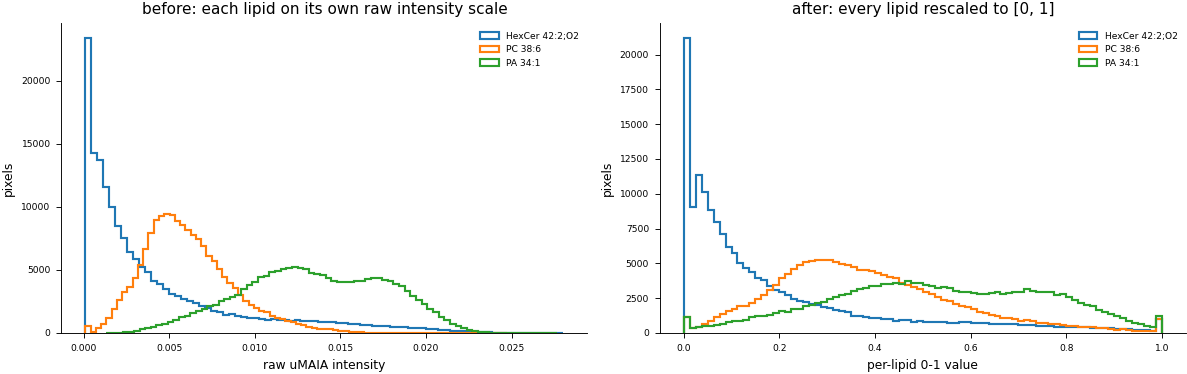

In [14]:
# pick three lipids of different classes to show the scale collapse
show = ["HexCer 42:2;O2", "PC 38:6", "PA 34:1"]
cols = [list(adata.var_names).index(s) for s in show]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for c, name in zip(cols, show):
    axes[0].hist(Xfull[:, c], bins=80, histtype="step", lw=1.4, label=name)
    axes[1].hist(X01[:, c], bins=80, histtype="step", lw=1.4, label=name)
axes[0].set_title("before: each lipid on its own raw intensity scale")
axes[0].set_xlabel("raw uMAIA intensity"); axes[0].set_ylabel("pixels"); axes[0].legend()
axes[1].set_title("after: every lipid rescaled to [0, 1]")
axes[1].set_xlabel("per-lipid 0-1 value"); axes[1].set_ylabel("pixels"); axes[1].legend()
plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** Before, the three lipids live on visibly different intensity ranges, so a raw
cross-lipid comparison would be meaningless. After, all three fill the same [0, 1] axis, and a value of
0.7 means "high for this lipid" no matter which lipid it is. That is the only sense in which MALDI
intensities are comparable across molecules, and it is why every cross-lipid step in the course runs on
this 0-to-1 representation.

❓ **QUESTION.** Per-lipid 0-1 scaling and uMAIA normalization solve *different* problems. State each
in one sentence. (uMAIA: make the same lipid comparable across sections by removing the technical
intensity offset between slides. min01: make different lipids comparable to each other by putting each
on its own 0-to-1 scale, because MALDI is only semi-quantitative within a lipid.)

## what you did, in one breath

You met the batch effect and saw why it is dangerous: the same lipid reads a different raw intensity on
different slides for purely technical reasons, so a naive control-versus-pregnant comparison would
partly measure the slide. You saw the empirical fact uMAIA stands on, the **bimodal log histogram**
with a stable background anchor and a drifting foreground mode. You read the **model**: a two-Gaussian
mixture per (lipid, section) whose foreground mean carries a **rank-1 batch shift** `gamma_a *
lambda_c`, fit by **MAP via SVI**, not by sampling. You unrolled the **correction** by hand, pushing
each value through its own CDF to a quantile and back through a shared reference inverse-CDF, and
watched two mismatched histograms snap into register both in simulation and on the real lipid. You
faced the **two-section corner case** honestly: uMAIA still removes the gross offset, but it is outside
its comfort zone, so we hide the condition labels from it, keep full sections, eyeball the histograms,
and run the real statistics ourselves later. And you applied the second, separate normalization,
**per-lipid 0-to-1 scaling**, because MALDI is only semi-quantitative within a lipid, confirming that
`cl.analysis.min01_per_lipid` is exactly the recipe you wrote.

Two rules to carry forward:

- **uMAIA makes the same lipid comparable across sections; min01 makes different lipids comparable to
  each other.** Different problems, both necessary.
- **Differential testing runs on the uMAIA-normalized, non-Harmonized data.** Never test on data whose
  batch correction also touched the biology, and with only two sections, never hand the normalizer the
  condition labels.

Next, in N4, we use this comparable data to build the embedding and start finding the lipid territories
called lipizones.